## Importing Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , accuracy_score
import warnings
import requests
from PIL import Image
from io import BytesIO
warnings.simplefilter(action='ignore', category=RuntimeWarning)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lung-cancer/survey lung cancer.csv


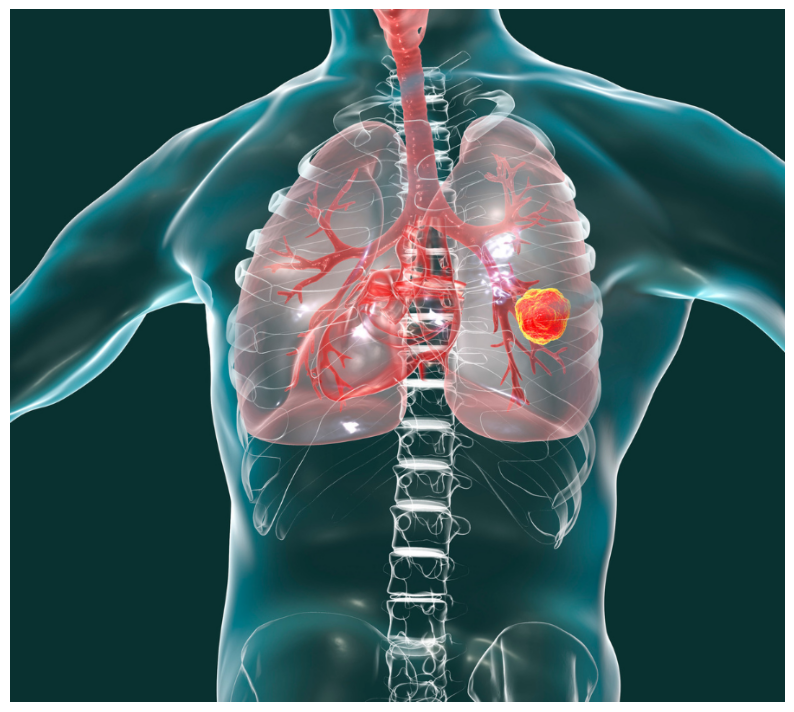

In [2]:
# URL'den resmi al
url = "https://lcfamerica.org/wp-content/uploads/2024/01/non-small-cell-lung-cancer-aspect-ratio-895-800.png"
response = requests.get(url)
image = Image.open(BytesIO(response.content))
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")  
plt.show()


## Define Columns

GENDER (Cinsiyet): Kişinin cinsiyetini belirtir (Erkek / Kadın).

AGE (Yaş): Kişinin yaşını gösterir.

SMOKING (Sigara İçme): Kişinin sigara içip içmediğini belirtir (Evet / Hayır).

YELLOW_FINGERS (Sarı Parmaklar): Sigara içen kişilerde sıklıkla görülen,
parmaklarda sararma durumunu ifade eder (Evet / Hayır).

ANXIETY (Anksiyete): Kişinin kaygı durumunu ifade eder (Evet / Hayır).

PEER_PRESSURE (Akran Baskısı): Kişinin akranları tarafından bir şeyler yapmaya zorlanıp zorlanmadığını ifade eder (Evet / Hayır).

CHRONIC DISEASE (Kronik Hastalık): Kişinin sürekli ve tedavi edilemeyen bir hastalığa sahip olup olmadığını belirtir (Evet / Hayır).

FATIGUE (Yorgunluk): Kişinin sürekli yorgunluk hissi yaşayıp yaşamadığını belirtir (Evet / Hayır).

ALLERGY (Alerji): Kişinin herhangi bir alerjisi olup olmadığını ifade eder (Evet / Hayır).

WHEEZING (Hışırtı): Solunum sırasında hışırtı gibi sesler duyulup duyulmadığını belirtir (Evet / Hayır).

ALCOHOL CONSUMING (Alkol Tüketimi): Kişinin alkol tüketip tüketmediğini ifade eder (Evet / Hayır).

COUGHING (Öksürük): Kişinin sık sık öksürüp öksürmediğini belirtir (Evet / Hayır).

SHORTNESS OF BREATH (Nefes Darlığı): Kişinin nefes almakta zorlanıp zorlanmadığını ifade eder (Evet / Hayır).

SWALLOWING DIFFICULTY (Yutma Güçlüğü): Kişinin yemek veya içecekleri yutarken zorluk çekip çekmediğini belirtir (Evet / Hayır).

CHEST PAIN (Göğüs Ağrısı): Kişinin göğüs bölgesinde ağrı hissedip hissetmediğini ifade eder (Evet / Hayır).

LUNG_CANCER (Akciğer Kanseri): Kişinin akciğer kanseri olup olmadığını belirtir (Evet / Hayır).

In [3]:
df = pd.read_csv("../input/lung-cancer/survey lung cancer.csv")
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


## Data Manuplation

In [4]:
df.shape

(309, 16)

In [5]:
# '1' sütunu hariç tüm sütunlar üzerinde işlemi yap
for col in df.columns:
    if col != 'LUNG_CANCER':
        df[col] = df[col].replace({'1': 0, '2': 1})


In [6]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [7]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [8]:
df.columns

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER'],
      dtype='object')

In [9]:
df.isnull().sum()


GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [10]:
df.duplicated().sum()


33

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df['AGE'].describe()

count    276.000000
mean      62.909420
std        8.379355
min       21.000000
25%       57.750000
50%       62.500000
75%       69.000000
max       87.000000
Name: AGE, dtype: float64

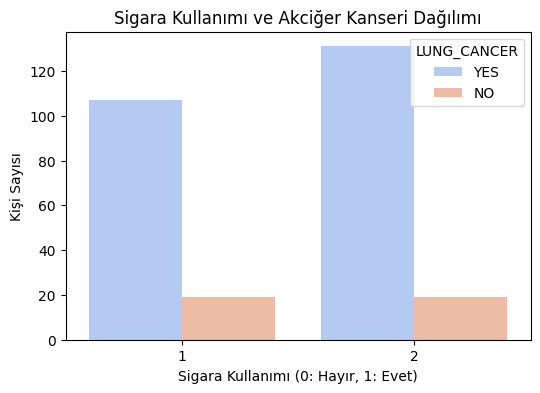

In [13]:
# Bar Plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='SMOKING', hue='LUNG_CANCER', palette='coolwarm')
plt.title("Sigara Kullanımı ve Akciğer Kanseri Dağılımı")
plt.xlabel("Sigara Kullanımı (0: Hayır, 1: Evet)")
plt.ylabel("Kişi Sayısı")
plt.show()

##  Cancer Distributions By Columns

In [14]:
# 'AGE' sütununu çıkarmak için sütunlar arasında yer alan 'AGE' sütununu hariç tutalım
for column in df.columns[:-1]:  # Son sütun 'LUNG_CANCER' olduğu için onu dışarıda bırakıyoruz
    if column != 'AGE':  # 'AGE' sütununu dışarıda bırakıyoruz
        count = df.groupby([column, 'LUNG_CANCER']).size().unstack(fill_value=0)
        print(f"Column: {column}")
        print(count)
        print("-" * 50)


Column: GENDER
LUNG_CANCER  NO  YES
GENDER              
F            21  113
M            17  125
--------------------------------------------------
Column: SMOKING
LUNG_CANCER  NO  YES
SMOKING             
1            19  107
2            19  131
--------------------------------------------------
Column: YELLOW_FINGERS
LUNG_CANCER     NO  YES
YELLOW_FINGERS         
1               25   92
2               13  146
--------------------------------------------------
Column: ANXIETY
LUNG_CANCER  NO  YES
ANXIETY             
1            26  113
2            12  125
--------------------------------------------------
Column: PEER_PRESSURE
LUNG_CANCER    NO  YES
PEER_PRESSURE         
1              28  108
2              10  130
--------------------------------------------------
Column: CHRONIC DISEASE
LUNG_CANCER      NO  YES
CHRONIC DISEASE         
1                25  107
2                13  131
--------------------------------------------------
Column: FATIGUE 
LUNG_CANCER  NO  YES


In [15]:
# 'LUNG_CANCER' değeri 1 olan satırları filtreleyelim
lung_cancer_1 = df[df['LUNG_CANCER'] == 2]

# 'LUNG_CANCER' = 1 olan satırlarda her bir sütunun yüzdesini hesaplayalım
for column in df.columns[:-1]:  # Son sütun 'LUNG_CANCER' olduğu için onu dışarıda bırakıyoruz
    if column != 'AGE':  # 'AGE' sütununu dışarıda bırakıyoruz
        # 'LUNG_CANCER' = 1 olan satırlarda her sütunun değerine göre yüzdesi
        percentage = lung_cancer_1[column].value_counts(normalize=True) * 100
        print(f"Column: {column}")
        print(percentage)
        print("-" * 50)


Column: GENDER
Series([], Name: proportion, dtype: float64)
--------------------------------------------------
Column: SMOKING
Series([], Name: proportion, dtype: float64)
--------------------------------------------------
Column: YELLOW_FINGERS
Series([], Name: proportion, dtype: float64)
--------------------------------------------------
Column: ANXIETY
Series([], Name: proportion, dtype: float64)
--------------------------------------------------
Column: PEER_PRESSURE
Series([], Name: proportion, dtype: float64)
--------------------------------------------------
Column: CHRONIC DISEASE
Series([], Name: proportion, dtype: float64)
--------------------------------------------------
Column: FATIGUE 
Series([], Name: proportion, dtype: float64)
--------------------------------------------------
Column: ALLERGY 
Series([], Name: proportion, dtype: float64)
--------------------------------------------------
Column: WHEEZING
Series([], Name: proportion, dtype: float64)
--------------------

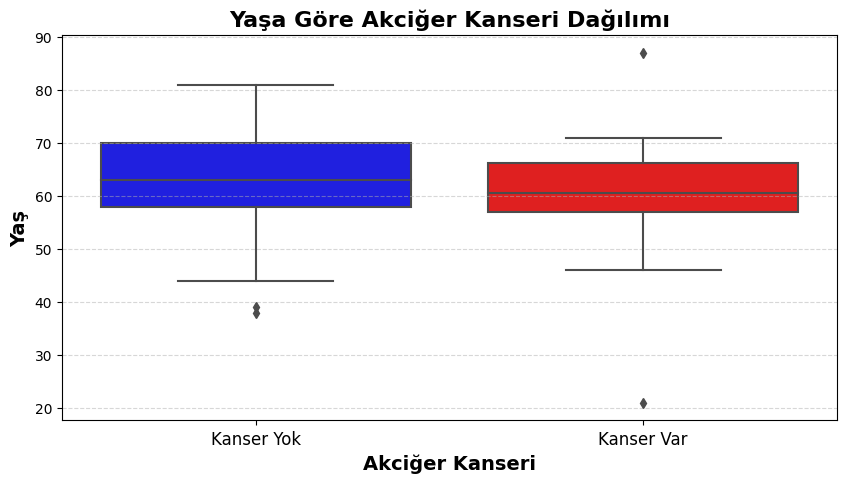

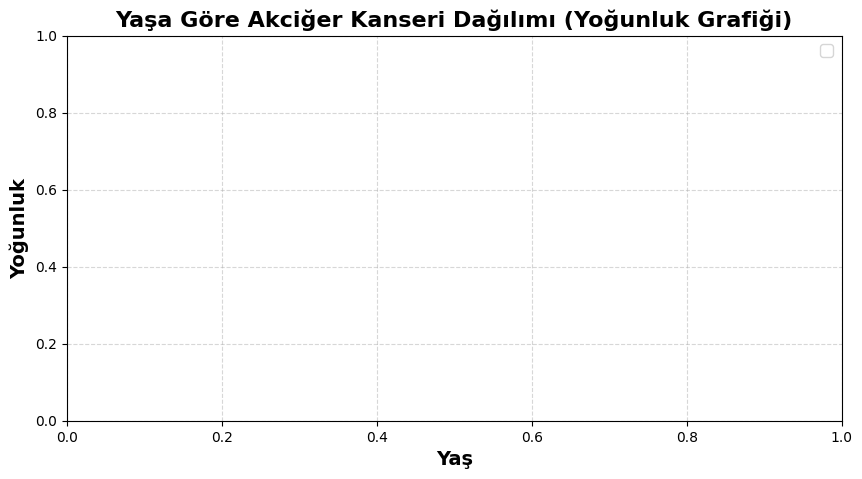

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot: Yaşa Göre Akciğer Kanseri Dağılımı
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["LUNG_CANCER"], y=df["AGE"], palette=["blue", "red"])
plt.xticks([0, 1], ["Kanser Yok", "Kanser Var"], fontsize=12)
plt.xlabel("Akciğer Kanseri", fontsize=14, fontweight="bold")
plt.ylabel("Yaş", fontsize=14, fontweight="bold")
plt.title("Yaşa Göre Akciğer Kanseri Dağılımı", fontsize=16, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# KDE Plot: Kanser Olan ve Olmayanların Yaş Dağılımı
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df["LUNG_CANCER"] == 0]["AGE"], fill=True, label="Kanser Yok", color="blue", alpha=0.5)
sns.kdeplot(df[df["LUNG_CANCER"] == 1]["AGE"], fill=True, label="Kanser Var", color="red", alpha=0.5)
plt.xlabel("Yaş", fontsize=14, fontweight="bold")
plt.ylabel("Yoğunluk", fontsize=14, fontweight="bold")
plt.title("Yaşa Göre Akciğer Kanseri Dağılımı (Yoğunluk Grafiği)", fontsize=16, fontweight="bold")
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [17]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['LUNG_CANCER']=encoder.fit_transform(df['LUNG_CANCER'])
df['GENDER']=encoder.fit_transform(df['GENDER'])
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


In [18]:
# Bağımsız ve bağımlı değişkenleri belirleme
X = df.drop(columns=['LUNG_CANCER'])  # Bağımsız değişkenler
y = df['LUNG_CANCER']  # Bağımlı değişken (Hedef)

In [19]:
# Veriyi eğitim ve test olarak ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
# Standartlaştırma (Önerilir)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [21]:
# Logistic Regression Modeli Oluşturma
model = LogisticRegression(
    penalty='l2',          # Düzenlileştirme terimi (L2 Ridge Regresyon)
    C=1.0,                 # Regularizasyon gücü (Düşük C daha fazla düzenlileştirme)
    solver='lbfgs',        # Optimizasyon algoritması
    max_iter=1000,         # Maksimum iterasyon sayısı
    random_state=42        # Sonuçların tekrarlanabilir olması için
)

In [22]:
# Modeli eğitme
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [23]:
# Test verisiyle tahmin yapma
y_pred = model.predict(X_test)

In [24]:
# Metrikleri hesaplama ve ekrana bastırma
print("Model Performans Metrikleri:\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=["No Cancer", "Cancer"]))

Model Performans Metrikleri:

Accuracy: 0.9286
              precision    recall  f1-score   support

   No Cancer       1.00      0.67      0.80        12
      Cancer       0.92      1.00      0.96        44

    accuracy                           0.93        56
   macro avg       0.96      0.83      0.88        56
weighted avg       0.93      0.93      0.92        56



In [25]:
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc


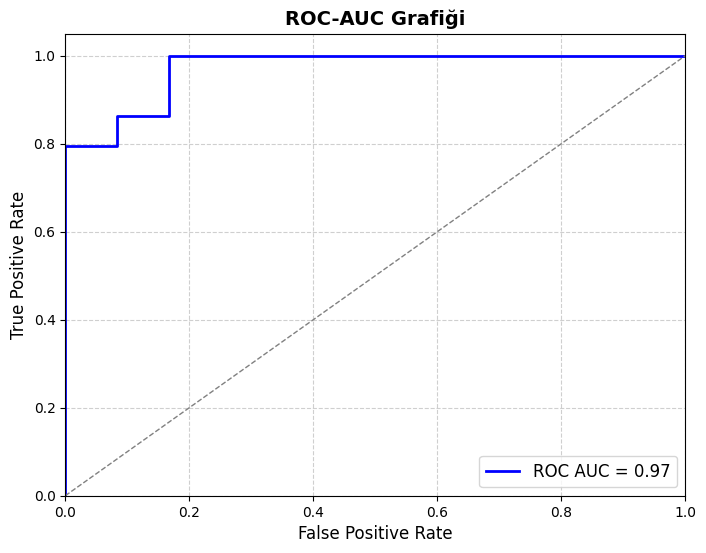

In [26]:
from sklearn.metrics import roc_curve, auc

# Tahmin edilen olasılıkları al
y_pred_prob = model.predict_proba(X_test)[:, 1]  # Pozitif sınıf için olasılıklar

# ROC eğrisi hesaplama
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# ROC-AUC Grafiği
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)  # Rastgele tahmin çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Grafiği', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
